In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")


In [2]:
np.random.seed(42)

n = 1000

locations = [
    "Chennai", "Bangalore", "Mumbai", "Delhi",
    "Hyderabad", "Pune", "Coimbatore", "Kochi"
]

furnishing = ["Unfurnished", "Semi-Furnished", "Fully-Furnished"]
property_types = ["Apartment", "Independent House", "Villa"]

data = {
    "Location": np.random.choice(locations, n),
    "Area_sqft": np.random.randint(500, 3001, n),
    "BHK": np.random.randint(1, 6, n),
    "Bathrooms": np.random.randint(1, 5, n),
    "Furnishing": np.random.choice(furnishing, n),
    "Property_Type": np.random.choice(property_types, n),
    "Floor": np.random.randint(1, 21, n),
    "Parking": np.random.choice(["Yes", "No"], n)
}

df = pd.DataFrame(data)

# Generate realistic rent approximately from the features
location_rate = {
    "Mumbai": 32,
    "Bangalore": 28,
    "Delhi": 25,
    "Chennai": 22,
    "Hyderabad": 20,
    "Pune": 21,
    "Kochi": 16,
    "Coimbatore": 14
}

furnishing_rate = {
    "Unfurnished": 0,
    "Semi-Furnished": 3000,
    "Fully-Furnished": 7000
}

property_rate = {
    "Apartment": 3000,
    "Independent House": 5000,
    "Villa": 10000
}

df["Rent"] = (
    df["Area_sqft"] * df["Location"].map(location_rate)
    + df["BHK"] * 2500
    + df["Bathrooms"] * 1500
    + df["Furnishing"].map(furnishing_rate)
    + df["Property_Type"].map(property_rate)
    + df["Floor"] * 200
    + np.random.normal(0, 5000, n)
)

df["Rent"] = df["Rent"].round().astype(int)

df.head()


,Location,Area_sqft,BHK,Bathrooms,Furnishing,Property_Type,Floor,Parking,Rent
0,Coimbatore,1724,3,2,Semi-Furnished,Apartment,14,No,46562
1,Delhi,1428,2,3,Unfurnished,Villa,3,Yes,57696
2,Hyderabad,2536,4,4,Fully-Furnished,Apartment,20,No,77982
3,Coimbatore,1424,4,2,Semi-Furnished,Villa,16,Yes,46897
4,Mumbai,2081,5,1,Unfurnished,Villa,2,No,86719


In [3]:
df.describe()


,Area_sqft,BHK,Bathrooms,Floor,Rent
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000
mean,1723.206000,3.058000,2.494000,10.84300,61127.71300
std,725.510409,1.423609,1.124824,5.73631,21019.83759
min,501.000000,1.000000,1.000000,1.00000,12608.00000
25%,1103.000000,2.000000,1.000000,6.00000,45251.25000
50%,1740.000000,3.000000,3.000000,11.00000,58618.00000
75%,2388.250000,4.000000,3.000000,16.00000,74931.00000
max,2997.000000,5.000000,4.000000,20.00000,124439.00000


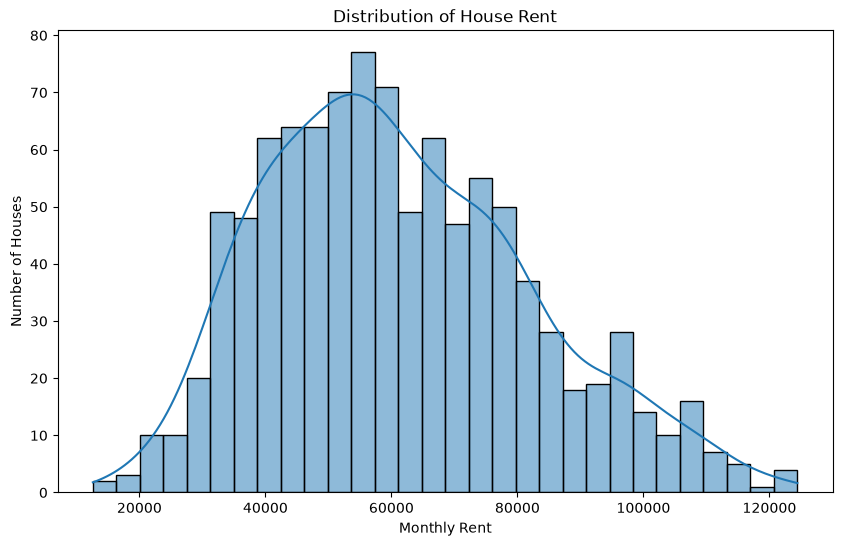

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Rent"], bins=30, kde=True)

plt.title("Distribution of House Rent")
plt.xlabel("Monthly Rent")
plt.ylabel("Number of Houses")

plt.show()


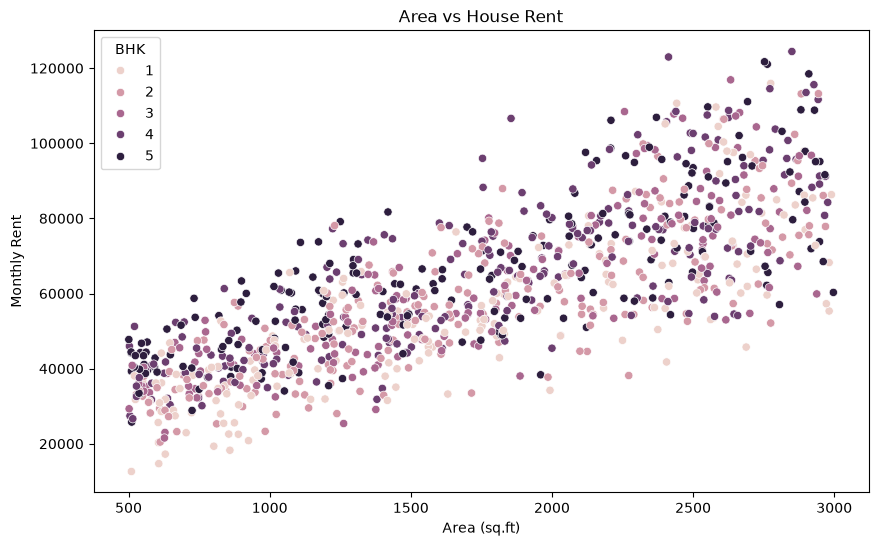

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Area_sqft",
    y="Rent",
    hue="BHK"
)

plt.title("Area vs House Rent")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Monthly Rent")

plt.show()


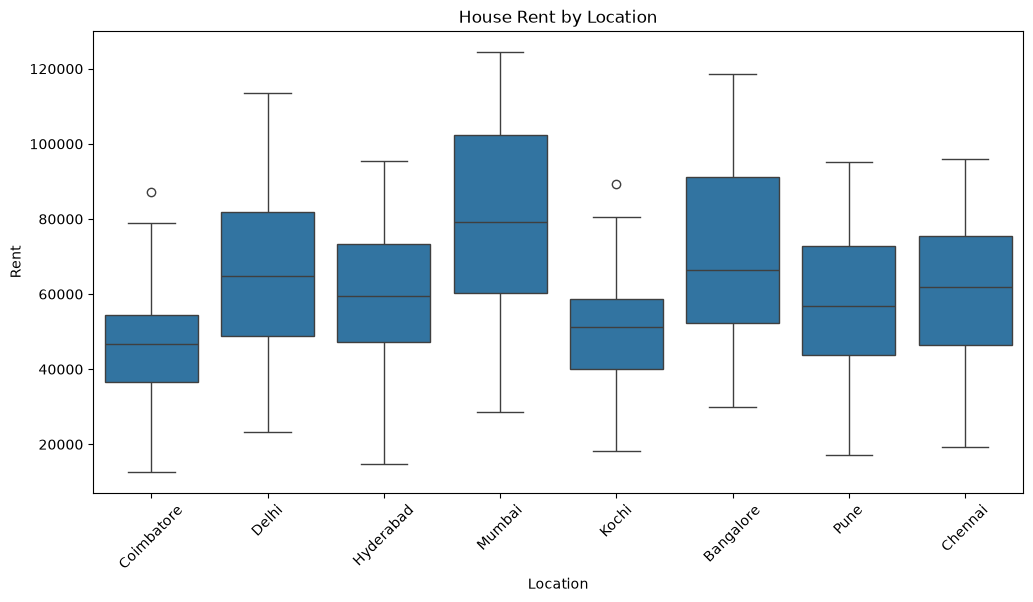

In [6]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Location",
    y="Rent"
)

plt.xticks(rotation=45)
plt.title("House Rent by Location")

plt.show()


In [7]:
X = df.drop("Rent", axis=1)
y = df["Rent"]

categorical_features = [
    "Location",
    "Furnishing",
    "Property_Type",
    "Parking"
]

numerical_features = [
    "Area_sqft",
    "BHK",
    "Bathrooms",
    "Floor"
]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (800, 8)
Testing data : (200, 8)


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


In [10]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2  :", round(linear_r2, 4))


Linear Regression
------------------
MAE : 4858.16
RMSE: 6257.63
R2  : 0.9083


In [11]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree")
print("-------------")
print("MAE :", round(tree_mae, 2))
print("RMSE:", round(tree_rmse, 2))
print("R2  :", round(tree_r2, 4))


Decision Tree
-------------
MAE : 7644.55
RMSE: 9577.7
R2  : 0.7852


In [12]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("-------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2  :", round(rf_r2, 4))


Random Forest
-------------
MAE : 5215.06
RMSE: 6364.38
R2  : 0.9052


In [13]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,4858.159112,6257.631469,0.908312
1,Decision Tree,7644.548437,9577.697912,0.785211
2,Random Forest,5215.064698,6364.375091,0.905158


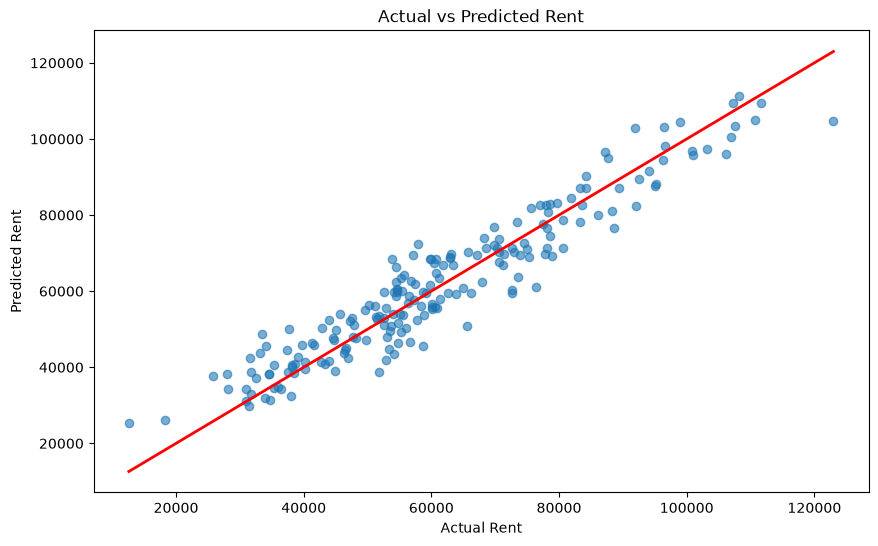

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.show()


In [15]:
new_house = pd.DataFrame({
    "Location": ["Chennai"],
    "Area_sqft": [1200],
    "BHK": [2],
    "Bathrooms": [2],
    "Furnishing": ["Semi-Furnished"],
    "Property_Type": ["Apartment"],
    "Floor": [5],
    "Parking": ["Yes"]
})

predicted_rent = rf_model.predict(new_house)[0]

print("House Details")
print("-------------")
print("Location      :", new_house["Location"].iloc[0])
print("Area          :", new_house["Area_sqft"].iloc[0], "sq.ft")
print("BHK           :", new_house["BHK"].iloc[0])
print("Bathrooms     :", new_house["Bathrooms"].iloc[0])
print("Furnishing    :", new_house["Furnishing"].iloc[0])

print("\nPredicted Monthly Rent: ₹", round(predicted_rent))


House Details
-------------
Location      : Chennai
Area          : 1200 sq.ft
BHK           : 2
Bathrooms     : 2
Furnishing    : Semi-Furnished

Predicted Monthly Rent: ₹ 44385


In [16]:
import joblib

joblib.dump(rf_model, "house_rent_prediction_model.pkl")

print("Model saved successfully!")


Model saved successfully!
